# 00 — Quanto di questo tracking è davvero osservato?

**La domanda.** I dati SkillCorner open sono *broadcast tracking*: ricavati dal
video della diretta, non da telecamere fisse installate nello stadio. Quando un
giocatore esce dall'inquadratura la sua posizione non sparisce dal file — viene
**estrapolata**. Il campo `is_detected` distingue le due cose.

**Perché conta più di qualunque altra domanda iniziale.** Una metrica che somma
distanze percorse su tutti i frame sta sommando anche tratti stimati. Una metrica
sul posizionamento difensivo poggia su posizioni che potrebbero non essere state
viste. Finché non so *quanto* e *dove* il dato è estrapolato, non posso scegliere
una domanda di ricerca sapendo se i dati la reggono.

Questo notebook produce il materiale del piano
[`00-capire-i-dati.md`](../plans/00-capire-i-dati.md): il paragrafo sui limiti che
dovrà finire nell'abstract.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lib import data

pd.set_option("display.width", 120)

## Cosa c'è nel dataset

Il README di `SkillCorner/opendata` parla di 10 partite. Nel clone di settembre
2026 ce ne sono di più: il dataset è cresciuto dopo l'edizione 2026 della Cup.

In [2]:
matches = data.list_matches()
print(f"{len(matches)} partite: {matches}")

righe = []
for mid in matches:
    m = data.load_match_meta(mid)
    righe.append({
        "match_id": mid,
        "data": m["date_time"][:10],
        "casa": m["home_team"]["short_name"],
        "ospite": m["away_team"]["short_name"],
        "risultato": f"{m['home_team_score']}-{m['away_team_score']}",
        "campo_m": f"{m['pitch_length']}x{m['pitch_width']}",
        "tracking_locale": data.tracking_available_locally(mid),
    })

inventario = pd.DataFrame(righe)
inventario

20 partite: [1874553, 1886347, 1899585, 1925299, 1927964, 1953632, 1959846, 1986691, 1996435, 1996436, 2006229, 2006363, 2007448, 2007721, 2010085, 2011166, 2013725, 2015213, 2016236, 2017461]


,match_id,data,casa,ospite,risultato,campo_m,tracking_locale
0,1874553,2024-11-23,Brisbane FC,Adelaide United,2-3,105x68,False
1,1886347,2024-11-30,Auckland FC,Newcastle,2-0,104x68,False
2,1899585,2024-12-07,Auckland FC,Wellington P FC,2-1,104x68,False
3,1925299,2024-12-21,Brisbane FC,Perth Glory,0-1,105x68,False
4,1927964,2024-12-22,Western Sydney,Wellington P FC,4-1,105x68,False
5,1953632,2024-12-31,CC Mariners,Melbourne City,1-1,105x68,False
6,1959846,2025-01-10,Melbourne V FC,Western United,3-4,106x68,False
7,1986691,2025-01-26,Western Sydney,Auckland FC,0-1,105x68,False
8,1996435,2025-02-01,Sydney FC,Adelaide United,4-1,105x68,False
9,1996436,2025-02-01,Auckland FC,Macarthur FC,2-1,104x68,False


**Le dimensioni del campo vanno lette, non assunte.** Se variano fra partite, ogni
metrica spaziale normalizzata va calcolata per partita.

La colonna `tracking_locale` dice se il file di tracking è stato davvero scaricato:
i `.jsonl` sono su **Git LFS** (~90 MB l'uno) e senza `git lfs pull` sul disco ci
sono solo puntatori da 133 byte. Quando manca, `lib/data.py` ripiega sullo
streaming da GitHub — più lento, ma il notebook gira lo stesso.

In [3]:
print(inventario.campo_m.value_counts().to_string())
print()
print("tracking scaricato in locale:", inventario.tracking_locale.sum(), "/", len(inventario))

campo_m
105x68    10
106x68     6
104x68     4

tracking scaricato in locale: 0 / 20


## Caricare con kloppy — e cosa kloppy perde per strada

`kloppy` è la libreria di PySport ed è quella che il tutorial ufficiale SkillCorner
usa. Nella submission è **obbligatorio** passare da qui, perché `load_open_data()`
scarica da GitHub e il regolamento vieta file di dati grossi nel repo.

In [4]:
from kloppy import skillcorner

ds = skillcorner.load_open_data(match_id=1886347, coordinates="skillcorner", limit=300)

print("fps:", ds.metadata.frame_rate)
print("squadre:", [t.name for t in ds.metadata.teams])
print("campo:", ds.metadata.pitch_dimensions.pitch_length, "x", ds.metadata.pitch_dimensions.pitch_width)

fps: 10
squadre: ['Auckland FC', 'Newcastle United Jets FC']
campo: 104 x 68


Qui però c'è un problema che condiziona tutto il resto del progetto.

In [5]:
frame = ds.frames[150]
pdata = list(frame.players_data.values())[0]

print("other_data:", pdata.other_data)
print("colonne di to_df():", [c for c in ds.to_df(engine="pandas").columns[:12]])

other_data: {}
colonne di to_df(): ['period_id', 'timestamp', 'frame_id', 'ball_state', 'ball_owning_team_id', 'ball_x', 'ball_y', 'ball_z', 'ball_speed', '51009_x', '51009_y', '51009_d']


> **`is_detected` non passa attraverso kloppy.** `other_data` è vuoto e `to_df()`
> restituisce solo `x`, `y`, distanza e velocità per giocatore.

Quindi il limite principale di questi dati **non è misurabile con la libreria
standard**: bisogna leggere il JSONL grezzo. È il motivo per cui esiste
`lib/data.py`, ed è un vincolo da ricordare al momento della submission — se la
metrica finale dipende da `is_detected`, il notebook di consegna dovrà scaricare
il JSONL da GitHub invece di usare solo `load_open_data()`.

## Quantificare l'estrapolazione

Una partita intera, in formato lungo: una riga per (frame, giocatore), con la
posizione della palla accanto.

In [6]:
MATCH_ID = 1886347

righe = []
for fr in data.iter_tracking(MATCH_ID):
    ball = fr.get("ball_data") or {}
    for p in fr["player_data"]:
        righe.append((fr["frame"], fr["period"], p["player_id"],
                      p["x"], p["y"], p["is_detected"],
                      ball.get("x"), ball.get("y")))

df = pd.DataFrame(righe, columns=["frame", "period", "player_id", "x", "y",
                                  "is_detected", "ball_x", "ball_y"])
print(f"{len(df):,} righe su {df.frame.nunique():,} frame")

956,076 righe su 43,458 frame


In [7]:
tasso = 100 * df.is_detected.mean()
print(f"Posizioni osservate: {tasso:.1f}%  ->  estrapolate: {100 - tasso:.1f}%")
print()
print("per tempo:")
print((100 * df.groupby("period").is_detected.mean()).round(1).to_string())

Posizioni osservate: 59.3%  ->  estrapolate: 40.7%

per tempo:
period
1    59.9
2    58.5


**Quasi due posizioni su cinque non sono state viste.** Questo è il numero che
qualunque risultato costruito su questi dati deve dichiarare.

Ma il dato aggregato nasconde la cosa che serve davvero sapere: l'estrapolazione
non è distribuita a caso. La telecamera segue la palla.

In [8]:
df["dist_palla"] = np.hypot(df.x - df.ball_x, df.y - df.ball_y)

bins = [0, 5, 10, 20, 30, 40, 150]
etichette = ["0-5", "5-10", "10-20", "20-30", "30-40", "40+"]
df["banda"] = pd.cut(df.dist_palla, bins, labels=etichette)

per_distanza = 100 * df.groupby("banda", observed=True).is_detected.mean()
per_distanza.round(1)

banda
0-5      87.0
5-10     84.5
10-20    77.7
20-30    60.8
30-40    40.3
40+      18.3
Name: is_detected, dtype: float64

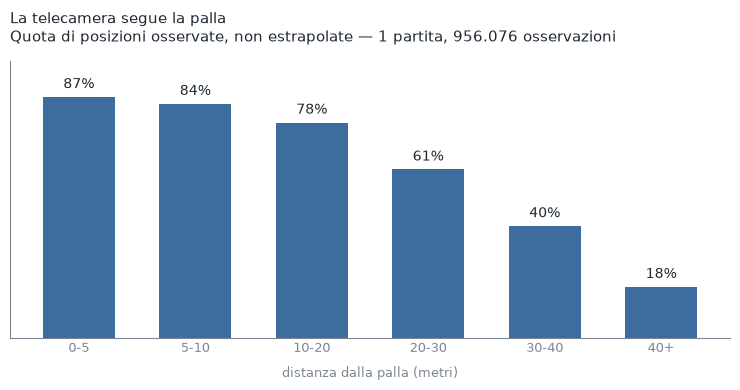

In [9]:
# Stile comune alle figure: assi discreti, una sola serie, valori etichettati
# direttamente invece che letti sull'asse.
INK, MUTED, ACCENT = "#1f2933", "#7b8794", "#3d6c9e"

def spoglia(ax):
    for lato in ("top", "right"):
        ax.spines[lato].set_visible(False)
    for lato in ("left", "bottom"):
        ax.spines[lato].set_color(MUTED)
        ax.spines[lato].set_linewidth(0.8)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)


fig, ax = plt.subplots(figsize=(7.5, 4))

ax.bar(per_distanza.index.astype(str), per_distanza.values,
       color=ACCENT, width=0.62)

for x, y in zip(range(len(per_distanza)), per_distanza.values):
    ax.text(x, y + 2, f"{y:.0f}%", ha="center", va="bottom",
            fontsize=10, color=INK)

ax.set_ylim(0, 100)
ax.set_yticks([])
ax.set_xlabel("distanza dalla palla (metri)", fontsize=9, color=MUTED, labelpad=8)
ax.set_title("La telecamera segue la palla\n"
             "Quota di posizioni osservate, non estrapolate — 1 partita, 956.076 osservazioni",
             fontsize=11, color=INK, loc="left", pad=14)
spoglia(ax)
plt.tight_layout()
plt.show()

Il gradiente è netto: **vicino alla palla il dato è quasi sempre reale, oltre i 40
metri è quasi sempre stimato.**

La conseguenza pratica è forte. Qualunque metrica che descrive cosa succede
*lontano* dall'azione — il posizionamento del blocco difensivo mentre la squadra
attacca, i movimenti senza palla del lato debole, la distanza fra i reparti — sta
lavorando prevalentemente su posizioni inventate dall'algoritmo di estrapolazione.

## La stessa cosa vista per ruolo

Se la telecamera segue la palla, i ruoli che stanno strutturalmente lontano dalla
palla devono essere i meno osservati.

In [10]:
meta = data.load_match_meta(MATCH_ID)
ruoli = {p["id"]: p["player_role"]["acronym"]
         for p in meta["players"] if p.get("player_role")}

per_giocatore = (df.groupby("player_id").is_detected
                   .agg(osservato="mean", frame="size")
                   .query("frame > 1000"))
per_giocatore["ruolo"] = per_giocatore.index.map(ruoli)

per_ruolo = (100 * per_giocatore.groupby("ruolo").osservato.mean()).sort_values()
per_ruolo.round(1)

ruolo
GK     14.8
CB     47.6
RCB    49.5
LCB    50.3
RB     61.5
CF     61.7
LB     62.1
LDM    62.8
LW     70.3
AM     71.8
DM     72.2
RW     72.3
RDM    73.3
Name: osservato, dtype: float64

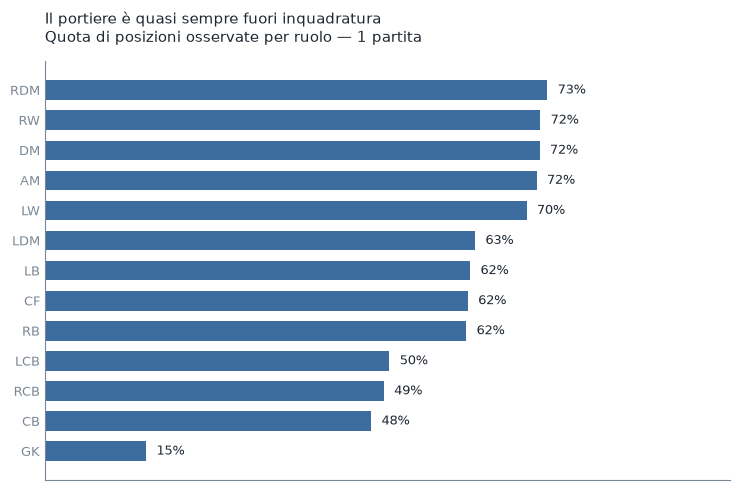

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5))

ax.barh(per_ruolo.index, per_ruolo.values, color=ACCENT, height=0.65)

for y, v in zip(range(len(per_ruolo)), per_ruolo.values):
    ax.text(v + 1.5, y, f"{v:.0f}%", va="center", ha="left",
            fontsize=9.5, color=INK)

ax.set_xlim(0, 100)
ax.set_xticks([])
ax.set_title("Il portiere è quasi sempre fuori inquadratura\n"
             "Quota di posizioni osservate per ruolo — 1 partita",
             fontsize=11, color=INK, loc="left", pad=14)
spoglia(ax)
plt.tight_layout()
plt.show()

L'ipotesi regge, e il caso estremo è severo: **la posizione di un portiere è
estrapolata circa l'85% del tempo.** I centrali difensivi stanno intorno al 50%.

Una conseguenza concreta: *qualunque analisi sul posizionamento del portiere
costruita su questi dati sarebbe in gran parte una descrizione dell'algoritmo di
estrapolazione di SkillCorner, non del portiere.* Vale la pena scriverlo, perché
è esattamente il tipo di idea che sembra attraente all'inizio di un progetto.

## Cosa portarsi via

| | |
|---|---|
| Partite disponibili | 20 (A-League 2024/25) — più delle 10 del README |
| Frequenza | 10 fps |
| Posizioni osservate | **59%** su una partita intera |
| Vicino alla palla (<5 m) | 87% osservato |
| Lontano dalla palla (>40 m) | 18% osservato |
| Portiere | 15% osservato |
| `is_detected` via kloppy | **non disponibile** — serve il JSONL grezzo |

**Per la scelta della domanda** (piano
[`01`](../plans/01-scegliere-la-domanda.md)): i dati sono affidabili *intorno alla
palla* e progressivamente inventati man mano che ci si allontana. Le domande
centrate sull'azione sono ben supportate; quelle sull'organizzazione collettiva
lontano dalla palla vanno o evitate, o affrontate dichiarando il limite e
verificando la robustezza.

### Cosa resta aperto

- Questi numeri vengono da **una sola partita**. Vanno ripetuti su tutte e 20 per
  sapere se il 59% è tipico o se varia con la regia televisiva.
- Non ho ancora guardato la **lunghezza dei buchi** di detection: 40% di frame
  estrapolati sparsi è un problema diverso da 40% concentrato in tratti lunghi.
  Nel primo caso l'interpolazione è quasi innocua, nel secondo no.
- `image_corners_projection` dice quale porzione di campo era inquadrata: è la
  via per verificare direttamente l'ipotesi della telecamera, invece di dedurla
  dalla distanza dalla palla.